In [24]:
import pandas as pd

data = pd.read_csv("../data/processed/model_dataset_with_holidays.csv", parse_dates=["date"])
data.head()

,date,trend_demand,temp_max,temp_min,temp_avg,precipitation,crowd_index,crowd_level,month,week_of_year,season_spring,season_summer,season_winter,is_holiday
0,2021-01-17,0.197531,9.000000,3.657143,0.156558,0.440000,0.257733,Low,1,2,False,False,True,0
1,2021-01-24,0.000000,8.671429,3.028571,0.149819,0.018621,0.241221,Low,1,3,False,False,True,0
2,2021-01-31,0.000000,10.885714,4.957143,0.218766,0.265517,0.212526,Low,1,4,False,False,True,0
3,2021-02-07,0.000000,14.957143,7.385714,0.328668,0.033103,0.291980,Low,2,5,False,False,True,0
4,2021-02-14,0.000000,12.614286,7.228571,0.268015,0.292414,0.221922,Low,2,6,False,False,True,0


In [25]:
X = data.drop(columns=["date", "crowd_index", "crowd_level"])
y = data["crowd_index"]

X.head()

,trend_demand,temp_max,temp_min,temp_avg,precipitation,month,week_of_year,season_spring,season_summer,season_winter,is_holiday
0,0.197531,9.000000,3.657143,0.156558,0.440000,1,2,False,False,True,0
1,0.000000,8.671429,3.028571,0.149819,0.018621,1,3,False,False,True,0
2,0.000000,10.885714,4.957143,0.218766,0.265517,1,4,False,False,True,0
3,0.000000,14.957143,7.385714,0.328668,0.033103,2,5,False,False,True,0
4,0.000000,12.614286,7.228571,0.268015,0.292414,2,6,False,False,True,0


In [26]:
split_index = int(len(data) * 0.8)

X_train = X[:split_index]
X_test = X[split_index:]

y_train = y[:split_index]
y_test = y[split_index:]

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (208, 11)
Test size: (52, 11)


In [27]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

xgb_model.fit(X_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_met

In [28]:
y_pred_xgb = xgb_model.predict(X_test)

In [29]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print("MAE:", mae_xgb)
print("RMSE:", rmse_xgb)
print("R2 Score:", r2_xgb)

MAE: 0.013036646121430571
RMSE: 0.017767267171817657
R2 Score: 0.9813415899857085


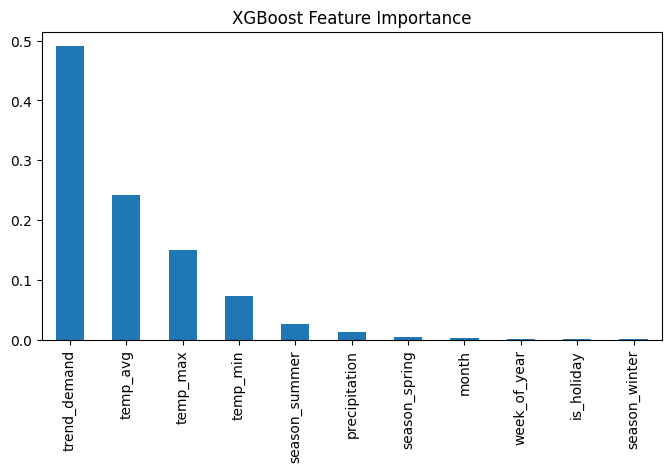

In [30]:
import matplotlib.pyplot as plt
import pandas as pd

importance_xgb = pd.Series(xgb_model.feature_importances_, index=X.columns)

importance_xgb.sort_values(ascending=False).plot(kind="bar", figsize=(8,4))
plt.title("XGBoost Feature Importance")
plt.show()

In [31]:
data["predicted_crowd"] = xgb_model.predict(X)

data.head()

,date,trend_demand,temp_max,temp_min,temp_avg,precipitation,crowd_index,crowd_level,month,week_of_year,season_spring,season_summer,season_winter,is_holiday,predicted_crowd
0,2021-01-17,0.197531,9.000000,3.657143,0.156558,0.440000,0.257733,Low,1,2,False,False,True,0,0.257777
1,2021-01-24,0.000000,8.671429,3.028571,0.149819,0.018621,0.241221,Low,1,3,False,False,True,0,0.242451
2,2021-01-31,0.000000,10.885714,4.957143,0.218766,0.265517,0.212526,Low,1,4,False,False,True,0,0.212902
3,2021-02-07,0.000000,14.957143,7.385714,0.328668,0.033103,0.291980,Low,2,5,False,False,True,0,0.292306
4,2021-02-14,0.000000,12.614286,7.228571,0.268015,0.292414,0.221922,Low,2,6,False,False,True,0,0.222276


In [32]:
data.to_csv("../data/processed/predictions.csv", index=False)

In [33]:
print(data.columns)

Index(['date', 'trend_demand', 'temp_max', 'temp_min', 'temp_avg',
       'precipitation', 'crowd_index', 'crowd_level', 'month', 'week_of_year',
       'season_spring', 'season_summer', 'season_winter', 'is_holiday',
       'predicted_crowd'],
      dtype='str')
